# Direction-aware cardinality — should the count term tell incoming from outgoing edges?

`synthetic_compare.ipynb` initializes every instance with a superposition of the schema concepts it satisfies. Its $\delta$-term ("repeated concepts are accumulated so cardinalities survive") is written as

$$\delta\sum_{(e,r,\cdot)\,\cup\,(\cdot,r,e)}\mathrm{code}(r)$$

i.e. **direction-blind**: an outgoing and an incoming $r$-edge add the *same* vector, so in this written form the count channel of an entity with *two outgoing* $r$-edges is identical to that of an entity with *one outgoing and one incoming* $r$-edge. The natural fix is the one already used for the binding terms: tag the incoming copy with $\mathrm{roll}(\mathrm{code}(r))$, which puts incoming counts into a (nearly) orthogonal subspace.

**Honest starting point.** The *implementation* (`concept_bound_vectors` in `scripts/_synthetic_compare.py`) already does this — the markdown formula above is a simplification of the code:

```python
rc_inv = np.roll(rc, 1)
if delta != 0.0:
    bump(s, rc, delta)        # outgoing:  code(r)
    bump(o, rc_inv, delta)    # incoming:  roll(code(r), 1)
```

So the question is not "why don't we do it" but "**does the direction tag actually buy anything, and is `roll` the right tag?**" — it has never been ablated. That is what this notebook measures.

## Hypotheses

- **H1 (information).** Direction-blindness aliases count patterns: $(\text{out}{=}2,\text{in}{=}0)$ and $(\text{out}{=}1,\text{in}{=}1)$ collapse to the same channel value. This can only hurt where labeled entities actually *receive* incoming edges of the target relation — the directional DLCC cardinality pairs tc09/tc10 ($\geq 2\,r$ vs $\geq 2\,r^-$) and tc11/tc12 ($\geq 2\,r.C$ vs $\geq 2\,r^-.C$) are the place to look, with tc01/tc02 ($\exists r.\top$ vs $\exists r^-.\top$) as the existence-only control.
- **H2 (geometry).** `roll` works because a circular shift of a high-dimensional random unit vector is nearly orthogonal to it: outgoing and incoming counts live in quasi-independent channels that a linear probe can read out separately. Any *fixed, decorrelating, norm-preserving* transform should do equally well — e.g. binding with a fixed random $\pm 1$ key.
- **H3 (a bad tag).** Negation ($-\mathrm{code}(r)$) is a *direction tag that loses information differently*: the count channel then encodes $\text{out}-\text{in}$, so $(2,0)$ vs $(0,2)$ separate but $(1,1)$ vs $(0,0)$ collapse. It should sit between `shared` and `rolled`.

## Experiment ladder

1. **Exact-count oracle (no embeddings).** Per labeled entity, exact out/in counts per relation (and per relation × neighbour class). Bayes error / LogReg accuracy with *undirected* (out+in summed) vs *directed* (out, in separate) features → the information-theoretic ceiling of each encoding.
2. **Init-space probe (embeddings, no finetuning).** Build the concept-bound init from pretrained P2 codes with a configurable direction tag ∈ {`shared`, `rolled`, `negated`, `keyed`} — applied to the incoming-edge code everywhere it appears ($\gamma$ binding *and* $\delta$ counts) — and fit LogReg directly on the init vectors. A `count_only` profile ($\alpha{=}\beta{=}\gamma{=}0,\ \delta{=}1$) isolates the cardinality channel; the `full` profile uses the complete recipe.
3. **Full pipeline.** Pretrain → bound init → 5 protected finetune epochs on tc09–tc12, per direction tag, against the cached `vanilla` / `p2_bound` numbers from `synthetic_compare.ipynb`.

In [1]:
"""Setup: paths, shared configuration (mirrors synthetic_compare.ipynb)."""
import json
import pickle
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

ROOT = Path("..").resolve()
SCRIPTS = ROOT / "scripts"
COMPARE_ROOT = ROOT / "notebooks" / "synthetic_compare"  # walk/protograph caches live there
OUT_ROOT = ROOT / "notebooks" / "direction_aware_cardinality"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))

from _evaluate import load_labeled_txt, make_classifiers  # noqa: E402
from _maschine_init import stage1_vector_lookup  # noqa: E402
from _protograph_gen import iter_rdf_iris  # noqa: E402
from _synthetic_compare import (  # noqa: E402
    ensure_walks,
    load_materialized_types,
    make_eval_fn,
    new_skipgram_model,
    normalized_stage1_vectors,
    pretrain_protograph,
    protograph_init,
    train_with_eval,
    write_protographs,
)

# Directional DLCC pairs (outgoing / incoming):
#   tc01 / tc02 : exists r.T   vs exists r-.T    (existence control)
#   tc09 / tc10 : >=2 r.T      vs >=2 r-.T       (cardinality)
#   tc11 / tc12 : >=2 r.C      vs >=2 r-.C       (qualified cardinality)
TCS = ["tc01", "tc02", "tc09", "tc10", "tc11", "tc12"]
PIPELINE_TCS = ["tc09", "tc10", "tc11", "tc12"]
DIRECTION_TAGS = ("shared", "rolled", "negated", "keyed")

CFG = dict(
    dim=200,
    walks_per_entity=100,
    proto_walks_per_entity=200,
    depth=3,
    epochs=5,
    pretrain_epochs=5,
    finetune_alpha=0.0025,
    min_alpha=0.0001,
    target_norm=8.0,
    seed=42,
)


def tc_paths(tc: str) -> dict:
    tc_dir = ROOT / "v1" / "synthetic_ontology" / tc / "synthetic_ontology"
    return dict(
        ontology=tc_dir / "ontology.nt",
        graph=tc_dir / "graph.nt",
        config=tc_dir / "configuration.txt",
        train=tc_dir / "1000" / "train_test" / "train.txt",
        test=tc_dir / "1000" / "train_test" / "test.txt",
        cache=COMPARE_ROOT / tc,
        out=OUT_ROOT / tc,
    )


def target_relation(tc: str) -> str:
    txt = tc_paths(tc)["config"].read_text(encoding="utf-8")
    m = re.search(r"Target (?:property|edge): <([^>]+)>", txt)
    assert m, f"no target relation in configuration.txt of {tc}"
    return m.group(1)


def inner_iri(token: str) -> str:
    return token[1:-1] if token.startswith("<") and token.endswith(">") else token


for tc in TCS:
    for k, p in tc_paths(tc).items():
        if k in ("cache", "out"):
            continue
        assert p.is_file(), f"missing {k} for {tc}: {p}"
    tc_paths(tc)["out"].mkdir(parents=True, exist_ok=True)

print(f"Output root: {OUT_ROOT}")
print({tc: target_relation(tc) for tc in TCS})

Output root: /home/bnukhkadiev/Knowledge-Graphs/notebooks/direction_aware_cardinality
{'tc01': 'P_tc01_885', 'tc02': 'P_TC02_233', 'tc09': 'P_tc09_1339', 'tc10': 'P_tc10_391', 'tc11': 'P_tc11_144', 'tc12': 'P_tc12_1105'}


## Part A — exact-count oracle: how much label information lives in edge *direction*?

Before touching embeddings, measure the ceiling. For every labeled entity we count its exact out- and in-edges, then compare two encodings of the same graph neighbourhood:

- **undirected** — per relation, one feature: $\text{out}+\text{in}$ (what a truly direction-blind count term could encode at best);
- **directed** — per relation, two features: $(\text{out}, \text{in})$ (what a perfectly direction-tagged count term could encode at best).

Two granularities: features on the **target relation only** (with the empirical *Bayes error* — the irreducible error of the best possible classifier on that feature, computed by majority vote per feature value over all 1 000 labeled entities), and LogReg train→test accuracy on **all relations** and on **relation × neighbour-class pairs** (the qualified analogue, with ancestor-materialized classes — relevant for tc11/tc12).

If undirected ≈ directed on some TC, no direction tag can help there; where they diverge, Part B checks how much of the gap the vector encodings recover.

In [2]:
"""Exact out/in counts per labeled entity; Bayes error and LogReg oracle accuracies."""
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import accuracy_score


def labeled_splits(tc: str):
    p = tc_paths(tc)
    train_tokens, y_tr = load_labeled_txt(p["train"])
    test_tokens, y_te = load_labeled_txt(p["test"])
    return [inner_iri(t) for t in train_tokens], y_tr, [inner_iri(t) for t in test_tokens], y_te


def count_dicts(tc: str):
    """entity -> Counter of directed count features, for relation and (relation, class) keys."""
    p = tc_paths(tc)
    tr, _, te, _ = labeled_splits(tc)
    labeled = set(tr) | set(te)
    types = load_materialized_types(p["ontology"])

    rel_feats = {e: Counter() for e in labeled}
    qual_feats = {e: Counter() for e in labeled}
    for s, r, o in iter_rdf_iris(p["graph"]):
        if s in labeled:
            rel_feats[s][("out", r)] += 1
            for c in types.get(o, ()):
                qual_feats[s][("out", r, c)] += 1
        if o in labeled:
            rel_feats[o][("in", r)] += 1
            for c in types.get(s, ()):
                qual_feats[o][("in", r, c)] += 1
    return rel_feats, qual_feats


def drop_direction(feats: dict[str, Counter]) -> dict[str, Counter]:
    """Sum out- and in-counts into one direction-blind feature per key tail."""
    out = {}
    for e, ctr in feats.items():
        merged = Counter()
        for key, n in ctr.items():
            merged[key[1:]] += n  # strip the "out"/"in" head
        out[e] = merged
    return out


def logreg_acc(feats, tc) -> float:
    tr, y_tr, te, y_te = labeled_splits(tc)
    dv = DictVectorizer(sparse=True)
    x_tr = dv.fit_transform([{str(k): v for k, v in feats[e].items()} for e in tr])
    x_te = dv.transform([{str(k): v for k, v in feats[e].items()} for e in te])
    clf = make_classifiers(max_iter=1000, seed=CFG["seed"])["LogReg"]
    clf.fit(x_tr, y_tr)
    return float(accuracy_score(y_te, clf.predict(x_te)))


def bayes_error(values, labels) -> float:
    """Irreducible error of the best classifier on a discrete feature (majority per value)."""
    pos, neg = Counter(), Counter()
    for v, lab in zip(values, labels):
        (pos if lab == 1 else neg)[v] += 1
    return sum(min(pos[v], neg[v]) for v in set(pos) | set(neg)) / len(labels)


oracle_rows, profile_rows = [], []
for tc in TCS:
    rel = target_relation(tc)
    rel_feats, qual_feats = count_dicts(tc)
    tr, y_tr, te, y_te = labeled_splits(tc)
    ents = tr + te
    y_all = np.concatenate([y_tr, y_te])

    outs = np.array([rel_feats[e][("out", rel)] for e in ents])
    ins = np.array([rel_feats[e][("in", rel)] for e in ents])
    for lab in (1, 0):
        m = y_all == lab
        profile_rows.append(dict(
            tc=tc, label=lab, mean_out=outs[m].mean(), mean_in=ins[m].mean(),
            pct_with_in=float((ins[m] > 0).mean()),
        ))

    oracle_rows.append(dict(
        tc=tc,
        bayes_err_undirected=bayes_error(outs + ins, y_all),
        bayes_err_directed=bayes_error(list(zip(outs, ins)), y_all),
        rel_undirected=logreg_acc(drop_direction(rel_feats), tc),
        rel_directed=logreg_acc(rel_feats, tc),
        qual_undirected=logreg_acc(drop_direction(qual_feats), tc),
        qual_directed=logreg_acc(qual_feats, tc),
    ))

profile = pd.DataFrame(profile_rows).set_index(["tc", "label"]).round(3)
print("Target-relation degree profile of labeled entities (positives = 1, negatives = 0)")
display(profile)

oracle = pd.DataFrame(oracle_rows).set_index("tc").round(3)
print("\nOracle: Bayes error on the target relation (lower = better) and"
      "\nLogReg test accuracy on exact count features (higher = better)")
display(oracle)

Target-relation degree profile of labeled entities (positives = 1, negatives = 0)


mean_out  mean_in  pct_with_in
tc   label                                
tc01 1         1.012    0.650        0.007
     0         0.000    0.278        0.003
tc02 1         0.086    1.001        1.000
     0         0.084    0.000        0.000
tc09 1         2.000    0.193        0.126
     0         1.000    0.159        0.095
tc10 1         0.266    2.000        1.000
     0         0.252    1.000        1.000
tc11 1         2.000    0.000        0.000
     0         1.000    0.000        0.000
tc12 1         0.000    2.000        1.000
     0         0.000    1.000        1.000


Oracle: Bayes error on the target relation (lower = better) and
LogReg test accuracy on exact count features (higher = better)


,bayes_err_undirected,bayes_err_directed,rel_undirected,rel_directed,qual_undirected,qual_directed
tc,,,,,,
tc01,0.000,0.0,0.560,1.0,0.998,1.0
tc02,0.017,0.0,0.955,1.0,1.000,1.0
tc09,0.048,0.0,0.888,1.0,0.992,1.0
tc10,0.112,0.0,0.855,1.0,0.880,1.0
tc11,0.000,0.0,1.000,1.0,1.000,1.0
tc12,0.000,0.0,1.000,1.0,1.000,1.0


## Part B — the same question in vector space

The concept-bound init is re-implemented below with one knob, `direction_tag`, which controls the code added for an **incoming** edge $(s, r, e)$ — both in the $\gamma$ binding term and in the $\delta$ count term (outgoing edges always use plain $\mathrm{code}(r)$):

| tag | incoming code | intuition |
|---|---|---|
| `shared` | $\mathrm{code}(r)$ | direction-blind — the formula as written in `synthetic_compare.ipynb` |
| `rolled` | $\mathrm{roll}(\mathrm{code}(r), 1)$ | current implementation: fixed permutation, nearly orthogonal channel |
| `negated` | $-\mathrm{code}(r)$ | direction-aware but same 1-D channel: encodes out − in |
| `keyed` | $\mathrm{code}(r) \odot k$, fixed random $\pm 1$ key $k$ | alternative decorrelating tag (Hadamard binding with a direction key) |

We first sanity-check the geometry ($\cos$ between $\mathrm{code}(r)$ and its tagged copy), then probe each tag with LogReg **directly on the init vectors** — no finetuning, so differences are purely about what the init encodes. `count_only` ($\alpha{=}\beta{=}\gamma{=}0$) isolates the cardinality channel the user's question is about; `full` is the production recipe.

In [3]:
"""Concept-bound init with a configurable direction tag (+ cached P2 pretrain codes)."""


def direction_key(dim: int) -> np.ndarray:
    return np.random.default_rng(7).choice([-1.0, 1.0], size=dim).astype(np.float32)


def tag_code(rc: np.ndarray, tag: str) -> np.ndarray:
    """Code added for an INCOMING edge of relation r (outgoing always uses rc itself)."""
    if tag == "shared":
        return rc
    if tag == "rolled":
        return np.roll(rc, 1)
    if tag == "negated":
        return -rc
    if tag == "keyed":
        return rc * direction_key(rc.shape[0])
    raise ValueError(f"unknown direction tag {tag!r}")


def directional_bound_vectors(
    graph_nt: Path,
    ontology_nt: Path,
    stage1_vectors: dict[str, np.ndarray],
    *,
    direction_tag: str = "rolled",
    alpha: float = 1.0,
    beta: float = 1.0,
    gamma: float = 1.0,
    delta: float = 1.0,
    target_norm: float = 1.0,
) -> dict[str, np.ndarray]:
    """concept_bound_vectors from scripts/_synthetic_compare.py with the incoming-edge
    relation code parameterized by ``direction_tag`` (everywhere rc_inv appears)."""
    types = load_materialized_types(ontology_nt)

    def unit(v: np.ndarray) -> np.ndarray:
        n = float(np.linalg.norm(v))
        return v / n if n > 0 else v

    codes: dict[str, np.ndarray] = {}

    def code_of(inner: str) -> np.ndarray | None:
        cached = codes.get(inner)
        if cached is not None:
            return cached
        vec = stage1_vector_lookup(inner, stage1_vectors)
        if vec is None:
            return None
        u = unit(np.asarray(vec, dtype=np.float32))
        codes[inner] = u
        return u

    def class_mix(inners) -> np.ndarray | None:
        parts = [code_of(c) for c in inners]
        parts = [p for p in parts if p is not None]
        return unit(np.mean(parts, axis=0)) if parts else None

    acc: dict[str, np.ndarray] = {}

    def bump(ent: str, vec: np.ndarray, w: float) -> None:
        if ent not in acc:
            acc[ent] = np.zeros_like(vec)
        acc[ent] += w * vec

    for ent, cs in types.items():
        mix = class_mix(cs)
        if mix is not None and alpha != 0.0:
            bump(ent, mix, alpha)

    for s, r, o in iter_rdf_iris(graph_nt):
        rc = code_of(r)
        if rc is None:
            continue
        rc_inv = tag_code(rc, direction_tag)
        if delta != 0.0:
            bump(s, rc, delta)
            bump(o, rc_inv, delta)
        if beta != 0.0:
            for c in types.get(o, ()):
                cc = code_of(c)
                if cc is not None:
                    bump(s, unit(rc * cc), beta)
        if gamma != 0.0:
            for c in types.get(s, ()):
                cc = code_of(c)
                if cc is not None:
                    bump(o, unit(rc_inv * cc), gamma)

    norms = [float(np.linalg.norm(v)) for v in acc.values()]
    mean_norm = float(np.mean(norms)) if norms else 1.0
    scale = target_norm / mean_norm if mean_norm > 0 else 1.0
    return {
        f"<{ent}>": (vec * scale).astype(np.float32)
        for ent, vec in acc.items()
        if float(np.linalg.norm(vec)) > 0
    }


def stage1_codes(tc: str) -> tuple[dict[str, np.ndarray], float]:
    """Normalized P2 pretrain codes (same recipe as synthetic_compare), cached on disk."""
    pkl = tc_paths(tc)["out"] / "stage1_p2.pkl"
    if pkl.is_file():
        return pickle.loads(pkl.read_bytes())
    p = tc_paths(tc)
    p["cache"].mkdir(parents=True, exist_ok=True)
    proto_paths = write_protographs(p["ontology"], p["cache"])
    walks = ensure_walks(
        proto_paths["p2"], p["cache"] / "walks_p2.txt",
        walks_per_entity=CFG["proto_walks_per_entity"], depth=CFG["depth"],
        seed=CFG["seed"], ensure_triple_coverage=True,
    )
    pre = pretrain_protograph(
        walks, dim=CFG["dim"], epochs=CFG["pretrain_epochs"], seed=CFG["seed"]
    )
    stage1, used_norm = normalized_stage1_vectors(pre.wv, target_norm=CFG["target_norm"])
    pkl.write_bytes(pickle.dumps((stage1, used_norm)))
    return stage1, used_norm


# Tag geometry: cos(code(r), tagged code(r)) over all pretrained relation codes of tc09.
stage1, _ = stage1_codes("tc09")
rel_codes = np.stack([
    v / np.linalg.norm(v) for k, v in stage1.items() if inner_iri(k).startswith("P_")
])
geometry = pd.DataFrame({
    tag: [float(np.mean(np.einsum("ij,ij->i", rel_codes,
                                  np.stack([tag_code(rc, tag) for rc in rel_codes]))))]
    for tag in DIRECTION_TAGS
}, index=["mean cos(code, tagged code)"]).round(3)
print(f"{rel_codes.shape[0]} relation codes from the tc09 P2 pretrain")
display(geometry)

1355 relation codes from the tc09 P2 pretrain


,shared,rolled,negated,keyed
"mean cos(code, tagged code)",1.0,-0.044,-1.0,0.078


In [4]:
"""Init-space probe: LogReg directly on the concept-bound init vectors (no finetuning)."""
PROBE_JSON = OUT_ROOT / "probe_results.json"
PROFILES = {
    "count_only": dict(alpha=0.0, beta=0.0, gamma=0.0, delta=1.0),
    "full": dict(alpha=1.0, beta=1.0, gamma=1.0, delta=1.0),
}


def probe_matrix(bound: dict[str, np.ndarray], tokens: list[str]) -> np.ndarray:
    x = np.zeros((len(tokens), CFG["dim"]), dtype=np.float32)
    for i, tok in enumerate(tokens):
        v = bound.get(f"<{tok}>")
        if v is not None:
            x[i] = v
    return x


def init_probe(tc: str, tag: str, profile: str) -> float:
    p = tc_paths(tc)
    stage1, used_norm = stage1_codes(tc)
    bound = directional_bound_vectors(
        p["graph"], p["ontology"], stage1,
        direction_tag=tag, target_norm=used_norm, **PROFILES[profile],
    )
    tr, y_tr, te, y_te = labeled_splits(tc)
    clf = make_classifiers(max_iter=1000, seed=CFG["seed"])["LogReg"]
    clf.fit(probe_matrix(bound, tr), y_tr)
    return float(accuracy_score(y_te, clf.predict(probe_matrix(bound, te))))


probe_results = json.loads(PROBE_JSON.read_text()) if PROBE_JSON.is_file() else {}
t0 = time.time()
for tc in TCS:
    for profile in PROFILES:
        for tag in DIRECTION_TAGS:
            key = f"{tc}|{profile}|{tag}"
            if key not in probe_results:
                probe_results[key] = init_probe(tc, tag, profile)
                print(f"[{time.time()-t0:6.1f}s] {key:28s} acc={probe_results[key]:.3f}", flush=True)
PROBE_JSON.write_text(json.dumps(probe_results, indent=2) + "\n")

probe_df = pd.DataFrame([
    dict(tc=tc, profile=profile, tag=tag, acc=probe_results[f"{tc}|{profile}|{tag}"])
    for tc in TCS for profile in PROFILES for tag in DIRECTION_TAGS
])
for profile in PROFILES:
    table = (probe_df[probe_df.profile == profile]
             .pivot(index="tc", columns="tag", values="acc")[list(DIRECTION_TAGS)])
    table.loc["mean"] = table.mean()
    print(f"\nLogReg accuracy on init vectors — profile = {profile}")
    display(table.round(3))

[   2.4s] tc01|count_only|shared       acc=0.770


[   3.0s] tc01|count_only|rolled       acc=0.812


[   3.4s] tc01|count_only|negated      acc=0.515


[   4.6s] tc01|count_only|keyed        acc=0.807


[   6.5s] tc01|full|shared             acc=0.917


...

[  93.1s] tc12|full|keyed              acc=0.990



LogReg accuracy on init vectors — profile = count_only


tag,shared,rolled,negated,keyed
tc,,,,
tc01,0.770,0.812,0.515,0.808
tc02,0.942,0.970,0.950,0.970
tc09,0.790,0.902,0.775,0.898
tc10,0.838,0.982,0.820,0.980
tc11,0.792,0.840,0.855,0.838
tc12,0.988,0.992,0.990,0.992
mean,0.853,0.917,0.817,0.914



LogReg accuracy on init vectors — profile = full


tag,shared,rolled,negated,keyed
tc,,,,
tc01,0.918,0.958,0.925,0.968
tc02,0.950,0.972,0.955,0.962
tc09,0.868,0.925,0.870,0.915
tc10,0.742,0.885,0.778,0.832
tc11,0.930,0.938,0.928,0.930
tc12,0.988,0.992,0.990,0.990
mean,0.899,0.945,0.908,0.933


## Part C — does it survive the full pipeline?

Same recipe as `p2_bound` in `synthetic_compare.ipynb` (P2 pretrain → bound init at `TARGET_NORM = 8` mirrored into `syn1neg` → 5 protected finetune epochs at LR 0.0025), with only the direction tag varied. Run on the cardinality TCs tc09–tc12, where Part A/B locate the directional signal. `rolled` should reproduce the cached `p2_bound` numbers (same construction); `vanilla` and `p2_bound` reference rows come from `synthetic_compare/results.json`.

In [5]:
"""Full pretrain -> bound init -> protected finetune, per direction tag (cached)."""
from gensim.models.word2vec import LineSentence

PIPELINE_JSON = OUT_ROOT / "pipeline_results.json"


def pipeline_run(tc: str, tag: str) -> dict:
    p = tc_paths(tc)
    stage1, used_norm = stage1_codes(tc)
    inst_walks = ensure_walks(
        p["graph"],
        p["cache"] / f"walks_instance_w{CFG['walks_per_entity']}_d{CFG['depth']}.txt",
        walks_per_entity=CFG["walks_per_entity"], depth=CFG["depth"], seed=CFG["seed"],
    )
    bound = directional_bound_vectors(
        p["graph"], p["ontology"], stage1, direction_tag=tag, target_norm=used_norm,
    )
    model = new_skipgram_model(
        dim=CFG["dim"], alpha=CFG["finetune_alpha"], min_alpha=CFG["min_alpha"],
        seed=CFG["seed"], workers=16,
    )
    model.build_vocab(LineSentence(str(inst_walks)))
    protograph_init(
        model, stage1, p["ontology"], strategy="all_init",
        target_norm=used_norm, bound_vectors=bound,
    )
    accs = train_with_eval(
        model, inst_walks, epochs=CFG["epochs"], alpha=CFG["finetune_alpha"],
        min_alpha=CFG["min_alpha"], eval_fn=make_eval_fn(p["train"], p["test"]),
    )
    return dict(tc=tc, tag=tag, accs=accs, init_acc=accs[0], final_acc=accs[-1])


pipeline_results = json.loads(PIPELINE_JSON.read_text()) if PIPELINE_JSON.is_file() else {}
t0 = time.time()
for tc in PIPELINE_TCS:
    for tag in DIRECTION_TAGS:
        key = f"{tc}|{tag}"
        if key not in pipeline_results:
            pipeline_results[key] = pipeline_run(tc, tag)
            r = pipeline_results[key]
            print(f"[{time.time()-t0:6.1f}s] {key:16s} "
                  f"accs=[{' '.join(f'{a:.3f}' for a in r['accs'])}]", flush=True)
            PIPELINE_JSON.write_text(json.dumps(pipeline_results, indent=2) + "\n")

# Reference rows from synthetic_compare.ipynb (vanilla baseline + p2_bound = rolled tag).
compare_results = json.loads((COMPARE_ROOT / "results.json").read_text())
reference = {
    (tc, r["variant"]): r["final_acc"]
    for tc, rows in compare_results.items() for r in rows
    if tc in PIPELINE_TCS and r["variant"] in ("vanilla", "p2_bound")
}

rows = []
for tc in PIPELINE_TCS:
    row = dict(
        tc=tc,
        vanilla=reference.get((tc, "vanilla")),
        p2_bound_cached=reference.get((tc, "p2_bound")),
    )
    for tag in DIRECTION_TAGS:
        row[tag] = pipeline_results[f"{tc}|{tag}"]["final_acc"]
    rows.append(row)
pipeline_df = pd.DataFrame(rows).set_index("tc")
pipeline_df.loc["mean"] = pipeline_df.mean()
print("\nFinal LogReg test accuracy after 5 finetune epochs")
display(pipeline_df.round(3))

init_df = pd.DataFrame([
    {"tc": tc, **{tag: pipeline_results[f"{tc}|{tag}"]["init_acc"] for tag in DIRECTION_TAGS}}
    for tc in PIPELINE_TCS
]).set_index("tc")
init_df.loc["mean"] = init_df.mean()
print("\nAccuracy at initialization (epoch 0)")
display(init_df.round(3))

[  21.9s] tc09|shared      accs=[0.868 0.843 0.805 0.790 0.777 0.757]


[  44.8s] tc09|rolled      accs=[0.925 0.912 0.900 0.875 0.873 0.870]


[  68.7s] tc09|negated     accs=[0.870 0.865 0.833 0.828 0.825 0.815]


[  92.9s] tc09|keyed       accs=[0.915 0.915 0.897 0.897 0.887 0.890]


[ 114.1s] tc10|shared      accs=[0.743 0.743 0.743 0.728 0.705 0.725]


...

[ 371.8s] tc12|keyed       accs=[0.990 0.985 0.985 0.983 0.983 0.978]



Final LogReg test accuracy after 5 finetune epochs


,vanilla,p2_bound_cached,shared,rolled,negated,keyed
tc,,,,,,
tc09,0.635,0.848,0.758,0.870,0.815,0.890
tc10,0.668,0.802,0.725,0.868,0.730,0.812
tc11,0.608,0.908,0.888,0.922,0.832,0.930
tc12,0.662,0.980,0.980,0.988,0.952,0.978
mean,0.643,0.884,0.838,0.912,0.832,0.903



Accuracy at initialization (epoch 0)


,shared,rolled,negated,keyed
tc,,,,
tc09,0.868,0.925,0.870,0.915
tc10,0.742,0.885,0.778,0.832
tc11,0.930,0.938,0.928,0.930
tc12,0.988,0.992,0.990,0.990
mean,0.882,0.935,0.891,0.917


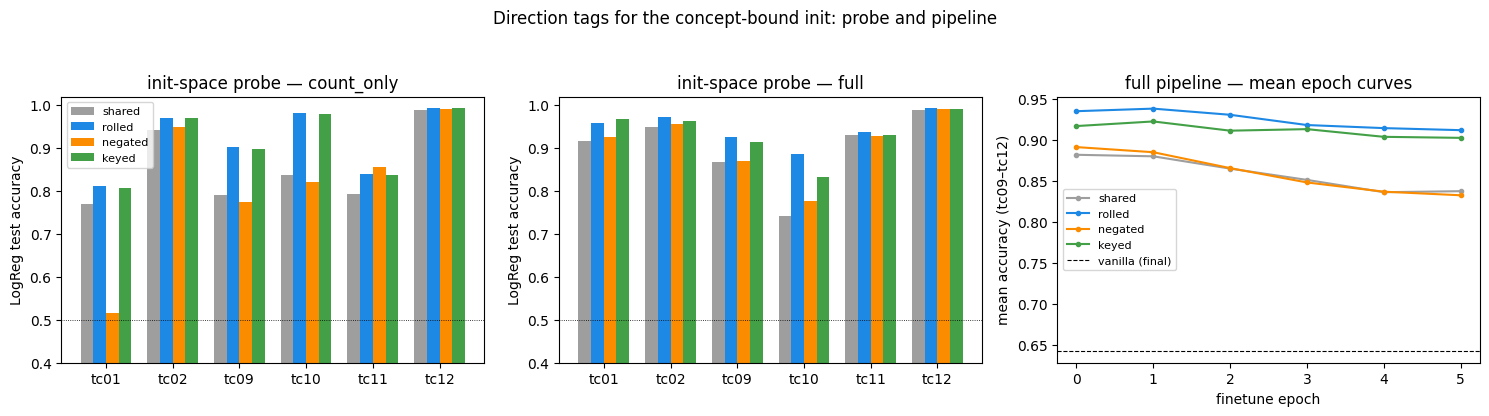

In [6]:
"""Plot: probe accuracies per tag (both profiles) and full-pipeline epoch curves."""
import matplotlib.pyplot as plt

TAG_COLORS = {"shared": "#9e9e9e", "rolled": "#1e88e5", "negated": "#fb8c00", "keyed": "#43a047"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, profile in zip(axes[:2], PROFILES):
    sub = probe_df[probe_df.profile == profile]
    width = 0.19
    xs = np.arange(len(TCS))
    for i, tag in enumerate(DIRECTION_TAGS):
        vals = [sub[(sub.tc == tc) & (sub.tag == tag)].acc.iloc[0] for tc in TCS]
        ax.bar(xs + (i - 1.5) * width, vals, width, label=tag, color=TAG_COLORS[tag])
    ax.set_xticks(xs)
    ax.set_xticklabels(TCS)
    ax.set_ylim(0.4, 1.02)
    ax.axhline(0.5, color="k", lw=0.6, ls=":")
    ax.set_title(f"init-space probe — {profile}")
    ax.set_ylabel("LogReg test accuracy")
axes[0].legend(fontsize=8)

ax = axes[2]
for tag in DIRECTION_TAGS:
    curves = np.array([pipeline_results[f"{tc}|{tag}"]["accs"] for tc in PIPELINE_TCS])
    ax.plot(range(curves.shape[1]), curves.mean(axis=0), marker="o", ms=3,
            label=tag, color=TAG_COLORS[tag])
ax.axhline(np.mean([reference[(tc, "vanilla")] for tc in PIPELINE_TCS]),
           color="k", lw=0.8, ls="--", label="vanilla (final)")
ax.set_xlabel("finetune epoch")
ax.set_ylabel("mean accuracy (tc09–tc12)")
ax.set_title("full pipeline — mean epoch curves")
ax.legend(fontsize=8)

fig.suptitle("Direction tags for the concept-bound init: probe and pipeline", fontsize=12)
fig.tight_layout(rect=(0, 0, 1, 0.94))
fig.savefig(OUT_ROOT / "direction_tag_comparison.png", dpi=150)
plt.show()

## Part D — protograph × method grid for the thesis tables

Parts B/C vary the direction tag on the **P2** protograph only. The thesis reports two tables that need the full pipeline run for every (test case, protograph, method) triple, so the appendix can average each method across **P1/P2/P3**. The heavy compute lives in `scripts/_direction_grid.py` (cache-aware, runnable headless); here we load it and render the two tables.

- **`no_card`** — the count-free, direction-agnostic baseline: bound init with the cardinality count term removed ($\delta=0$) and direction-blind binding (`tag=shared`). The four direction tags add the count term back on top of it.
- **`shared` / `rolled` / `negated` / `keyed`** — the full bound recipe ($\alpha{=}\beta{=}\gamma{=}\delta{=}1$) with that direction tag on the incoming-edge code.

The **main table** (`tab:direction_pipeline`) uses the P2 column on the cardinality cases tc09–tc12: the `no_card` baseline vs. the four tags. The **appendix table** (`app:direction-all`) covers all six directional test cases with each method averaged over the P1/P2/P3 bound inits.

In [ ]:
"""Part D: full (test case x protograph x method) grid -> the two thesis tables."""
from _direction_grid import PROTOS, compute_grid

CARD_TCS = ["tc09", "tc10", "tc11", "tc12"]
METHOD_ORDER = ["no_card", "shared", "rolled", "negated", "keyed"]

grid = compute_grid()  # cache-aware; heavy compute lives in scripts/_direction_grid.py


def grid_final(tc, kind, method):
    return grid[f"{tc}|{kind}|{method}"]["final_acc"]


# Main pipeline table: P2 init, cardinality TCs, no-card baseline + 4 direction tags.
main_tbl = pd.DataFrame(
    {m: [grid_final(tc, "p2", m) for tc in CARD_TCS] for m in METHOD_ORDER},
    index=CARD_TCS,
)
main_tbl.loc["mean"] = main_tbl.mean()
print("Main table (P2; final acc after 5 finetune epochs); "
      "no_card = bound init without the cardinality term (delta=0, direction-blind)")
display(main_tbl.round(3))

# Appendix table: all six directional TCs, each method averaged across P1/P2/P3.
appendix_tbl = pd.DataFrame(
    {m: [float(np.mean([grid_final(tc, k, m) for k in PROTOS])) for tc in TCS]
     for m in METHOD_ORDER},
    index=list(TCS),
)
appendix_tbl.loc["mean"] = appendix_tbl.mean()
print("\nAppendix table (final acc averaged across the P1/P2/P3 bound inits)")
display(appendix_tbl.round(3))

## Conclusions

**H1 confirmed — direction is real, label-relevant information, and a direction-blind count term loses it.**

1. **Oracle (Part A).** Exact *directed* counts solve all six TCs perfectly (LogReg 1.000 everywhere). Collapsing direction costs up to 14.5 accuracy points (tc10: 0.855, tc09: 0.888) and raises the Bayes error of the target-relation count from 0 to 0.112 (tc10) / 0.048 (tc09). The aliasing is in the data: ~10–13 % of tc09's labeled entities also *receive* edges of the target relation, and on tc10 every labeled entity has both in- and (some) out-edges — exactly the $(\text{out}, \text{in})$ patterns that an out+in sum collapses.
2. **Init space (Part B).** With the cardinality channel isolated (`count_only`), `rolled` beats `shared` by **+6.4 points** on average (0.917 vs 0.853), with the biggest gaps where Part A predicted them: tc10 **+14.5** (0.982 vs 0.838) and tc09 **+11.2** (0.902 vs 0.790). In the `full` recipe the binding terms absorb part of it, but the gap is still **+4.6** mean and **+14.3** on tc10.
3. **Full pipeline (Part C).** The protected finetune cannot repair a direction-blind init: final accuracy drops from **0.912** (`rolled`, which reproduces the cached `p2_bound` row within run-to-run variance) to **0.838** (`shared`) on tc09–tc12 — still far above vanilla (0.643), but a consistent ~7-point hit, worst on tc10 (0.868 → 0.725).

**H2 confirmed — `roll` is nothing special, just a cheap decorrelating tag.** A fixed random ±1 key (`keyed`, cos ≈ 0.08 to the original code, vs ≈ −0.04 for `roll`) performs on par everywhere: probe means within ~1 point, pipeline mean 0.903 vs 0.912. Any fixed, norm-preserving, decorrelating transform gives incoming counts their own quasi-orthogonal channel; `roll` is simply the cheapest one.

**H3 confirmed — negation is a direction tag that fails differently.** `negated` encodes $\text{out}-\text{in}$ in the *same* 1-D channel: it lands at `shared` level overall (pipeline 0.832) and collapses to chance (0.515) on the tc01 count-only probe, where positives (out = 1) and the in-edge hubs among negatives cancel against each other.

**Two things we did not expect.**

- tc11/tc12 do *not* actually need the direction tag at the oracle level (undirected Bayes error = 0: their positives and negatives differ in the plain count of the target relation, and there are no in-edge confusers on tc11 at all). The qualified-cardinality wins of the direction tag in Parts B/C there are small, consistent with that.
- On tc01, direction-blindness does not just shrink the margin — it makes the task **linearly inseparable** (undirected all-relation LogReg: 0.560 despite a Bayes error of ~0). A handful of negative hub entities with ~90 incoming target-relation edges sit *above* the positives in the summed count, so the decision boundary in the collapsed channel is non-monotone. Since everything downstream (the probe, the DLCC protocol) is a linear classifier, this failure mode matters beyond raw information loss.

**Bottom line.** The user-question's intuition is right, and it is in fact what the code already does: `concept_bound_vectors` tags incoming edges with `roll(code(r), 1)` in both the $\gamma$ and $\delta$ terms — only the formula written in `synthetic_compare.ipynb` reads direction-blind. This ablation shows the tag is worth ~7 accuracy points end-to-end on the cardinality TCs (up to ~14 on the inverse-direction ones), so the $\delta$-term in that notebook's markdown should be written as it is implemented:

$$\delta\Big(\sum_{(e,r,\cdot)}\mathrm{code}(r) \;+\; \sum_{(\cdot,r,e)}\mathrm{roll}(\mathrm{code}(r))\Big)$$